## Long Gaps (Weeks to Months) (7–30 days) (168 hours–720 hours)

In [2]:
# Import libraries
import warnings
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

## 1. Load data

In [3]:
def load_cleaned_data(station_id, directory = "./output"):
    filename = Path(directory) / f"Station{station_id}_filled_mediumgaps.csv"
    df = pd.read_csv(filename, parse_dates=[0], index_col=0)
    df.index = pd.DatetimeIndex(df.index, freq="H")
    return df

def load_missing_data(station_id, directory="../EDA_2025/missing_data"):
    filename = f"{directory}/Station{station_id}_missing_data.csv"
    df = pd.read_csv(filename, parse_dates=["Start Timestamp", "End Timestamp"])
    return df

In [3]:
load_cleaned_data(1).head()

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Tair,RH,Wind speed,Wind direction,Srad,Ppt
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,-1.090,81.5,1.052,52.27,0.63,0.0
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,-1.038,81.7,0.959,46.71,0.62,0.0
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,-0.981,82.0,1.062,52.04,0.60,0.0
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,-0.814,81.9,0.887,58.91,0.64,0.0
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,-0.805,90.0,0.828,16.55,0.20,0.0


## 2. Filter long gaps

In [4]:
def filter_long_gaps(df_missing, parameter, min_gap=168, max_gap=720):
    df_missing["Number Missing"] = pd.to_numeric(df_missing["Number Missing"], errors="coerce")
    mask = (
        (df_missing["Parameter"] == parameter)
        & (df_missing["Number Missing"] >= min_gap)
        & (df_missing["Number Missing"] <= max_gap)
    )
    return df_missing.loc[mask].sort_values("Start Timestamp")

## 3. Baseline （Seasonal‑hour mean + slow linear trend）

In [5]:
def baseline_predict(series, gap_slice):
    # seasonal mean  
    seasonal_key   = series.index.strftime("%m-%d-%H")
    seasonal_means = series.groupby(seasonal_key).transform("mean")

    # global linear trend
    mask_not_na = series.notna()
    x_train = series.index[mask_not_na].view("int64").reshape(-1, 1)
    y_train = series[mask_not_na].to_numpy()
    trend_model = LinearRegression().fit(x_train, y_train)

    # trend prediction for the full index
    x_full   = series.index.view("int64").reshape(-1, 1)
    trend    = trend_model.predict(x_full)

    # combine & return slice
    baseline = seasonal_means + (trend - trend.mean())
    return baseline.loc[gap_slice]

## Feature Engineering

In [6]:
def make_features(df, ts, param, window=168):
    hist = df.loc[ts - timedelta(hours=window) : ts - timedelta(hours=1)]
    feat = {
        "last": hist[param].iloc[-1] if not hist.empty else np.nan,
        "mean": hist[param].mean(),
        "std": hist[param].std(),
        "ppt_sum7d":  hist["Ppt"].sum(),                          # 168h
        "ppt_sum24h": hist["Ppt"].tail(24).sum(),                 # 24h
        "ppt_last3h": hist["Ppt"].tail(3).sum(),                  # 3h
        "ppt_flag":   int(hist["Ppt"].tail(6).sum() > 0),         # check if within 6h rain
        "temp_mean": hist["Tair"].mean(),
        "doy": ts.dayofyear,
        "hour": ts.hour,
    }
    return pd.Series(feat)

In [7]:
def rolling_fill(model, df, idx, param):
    preds = []
    for ts in idx:
        x_row = make_features(df, ts, param).to_frame().T
        y_hat = model.predict(x_row)[0]
        preds.append(y_hat)
        df.at[ts, param] = y_hat
    return pd.Series(preds, index=idx)

## 4. Random Forest

In [8]:
def train_random_forest(df, param):
    idx = df[param].dropna().index
    X = pd.DataFrame([make_features(df, t, param) for t in idx])
    y = df[param].loc[idx]
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    return rf

## 5. LightGBM

In [9]:
def train_lightgbm(df, param):
    idx = df[param].dropna().index
    X = pd.DataFrame([make_features(df, t, param) for t in idx])
    y = df[param].loc[idx]
    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05)
    model.fit(X, y)
    return model

## 6.XGBoost

In [10]:
def train_xgb(df, param):
    idx = df[param].dropna().index
    X   = pd.DataFrame([make_features(df, t, param) for t in idx])
    y   = df.loc[idx, param]

    xgb = XGBRegressor(
        n_estimators   = 300,
        learning_rate  = 0.05,
        max_depth      = 6,
        subsample      = 0.8,
        colsample_bytree = 0.8,
        objective      = "reg:squarederror",
        n_jobs         = -1,
        random_state   = 42,
        tree_method    = "hist"         
    )
    xgb.fit(X, y)
    return xgb

In [11]:
def fill_long_gaps(df, gaps, param, best):
    if best == "rf":
        model = train_random_forest(df.copy(), param)
    elif best == "lgbm":
        model = train_lightgbm(df.copy(), param)
    else:
        model = None  

    filled = df[param].copy()
    logs = []

    for _, g in gaps.iterrows():
        idx = pd.date_range(g["Start Timestamp"], g["End Timestamp"], freq="H")
        if best == "baseline":
            preds = baseline_predict(filled, idx)
        else:
            preds = rolling_fill(model, df.copy(), idx, param)
        filled.loc[idx] = preds
        logs.append({"start": g["Start Timestamp"], "end": g["End Timestamp"], "method": best})
    return filled, pd.DataFrame(logs)

In [12]:
def make_synthetic_gaps(series, n = 10, min_len = 168, max_len = 720, seed = 2025):
    rng = np.random.default_rng(seed)
    complete = series.dropna().index
    gaps = []
    while len(gaps) < n:
        start = rng.choice(complete[:-max_len])
        length = rng.integers(min_len, max_len + 1)
        idx = pd.date_range(start, periods=length, freq="H")
        if series.loc[idx].notna().all():
            gaps.append((idx[0], idx[-1]))
    return gaps

In [13]:
def evaluate_methods_on_fake_gaps(df, fake_gaps, param):
    rf   = train_random_forest(df, param)
    lg   = train_lightgbm(df, param)
    xgb  = train_xgb(df, param)

    rows = []
    for (s, e) in fake_gaps:
        idx   = pd.date_range(s, e, freq="H")
        truth = df.loc[idx, param].copy()
        df.loc[idx, param] = np.nan

        for m_name, y_pred in {
            "baseline": baseline_predict(df[param], idx),
            "rf"      : rolling_fill(rf,  df, idx, param),
            "lgbm"    : rolling_fill(lg,  df, idx, param),
            "xgb"     : rolling_fill(xgb, df, idx, param),
        }.items():
            rows.append({
                "method": m_name,
                "rmse"  : mean_squared_error(truth, y_pred, squared=False),
                "mae"   : mean_absolute_error(truth, y_pred)
            })
        df.loc[idx, param] = truth
    return pd.DataFrame(rows)

In [16]:
palette = {"baseline": "#555555", "rf": "#1f77b4",
           "lgbm": "#ff7f0e", "xgb": "#2ca02c"}

def plot_cv_bar(cv_tbl: pd.DataFrame, metric: str = "rmse"):
    assert metric in ("rmse", "mae")
    avg = cv_tbl.groupby("method")[metric].mean().sort_values()
    title = f"CV AVG {metric.upper()}"
    fig, ax = plt.subplots(figsize=(4, 2.6))
    avg.plot.bar(ax=ax, color=[palette[m] for m in avg.index])
    ax.set_ylabel(metric.upper()); ax.set_xlabel("")
    ax.set_title(title)
    plt.tight_layout(); plt.show()
    return avg

def plot_one_gap(df_true, df_work, gap, param, rf_model, lg_model, xgb_model, methods=("baseline", "rf", "lgbm", "xgb")):
    s, e  = gap
    idx   = pd.date_range(s, e, freq="H")
    truth = df_true.loc[idx, param]

    preds = {
        "baseline": baseline_predict(df_work[param], idx),
        "rf"      : rolling_fill(rf_model, df_work.copy(), idx, param),
        "lgbm"    : rolling_fill(lg_model, df_work.copy(), idx, param),
        "xgb"     : rolling_fill(xgb_model, df_work.copy(), idx, param),
    }

    plt.figure(figsize=(10, 4))
    truth.plot(label="Truth", lw=1.6, color="black")
    for m in methods:
        preds[m].plot(label=m.upper(), lw=1.2, color=palette[m])
    plt.axvspan(s, e, color="grey", alpha=0.1)
    plt.title(f"Synthetic Gap — Truth vs. Predictions ({param})")
    plt.ylabel(param); plt.legend(); plt.tight_layout(); plt.show()


In [15]:
STATION = 1
PARAM   = "SWC_20"

df_full = load_cleaned_data(STATION)
df_ref  = load_cleaned_data(3)
df_full["Ppt"] = df_full["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
fake_gaps = make_synthetic_gaps(df_full[PARAM], n=10)

cv_res = evaluate_methods_on_fake_gaps(df_full.copy(), fake_gaps, PARAM)
cv_res.head()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1700
[LightGBM] [Info] Number of data points in the train set: 57863, number of used features: 8
[LightGBM] [Info] Start training from score 0.138471


,method,rmse,mae
0,baseline,0.026524,0.021741
1,rf,0.060981,0.054961
2,lgbm,0.040344,0.033566
3,xgb,0.008006,0.006029
4,baseline,0.061445,0.058561


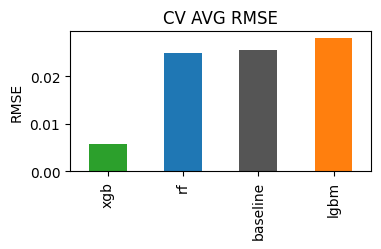


Average RMSE：


method
xgb         0.005714
rf          0.024974
baseline    0.025491
lgbm        0.028091
Name: rmse, dtype: float64

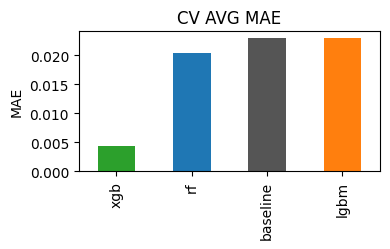


Average MAE：


method
xgb         0.004264
rf          0.020489
baseline    0.023026
lgbm        0.023027
Name: mae, dtype: float64


Best RMSE Method：XGB

Best MAE Method：XGB


In [16]:
avg_rmse = plot_cv_bar(cv_res, metric="rmse")
print("\nAverage RMSE：")
display(avg_rmse)

avg_mae = plot_cv_bar(cv_res, metric="mae")
print("\nAverage MAE：")
display(avg_mae)

best_rmse_method = avg_rmse.idxmin()
best_mae_method  = avg_mae.idxmin()
print(f"\nBest RMSE Method：{best_rmse_method.upper()}")
print(f"\nBest MAE Method：{best_mae_method.upper()}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1700
[LightGBM] [Info] Number of data points in the train set: 57863, number of used features: 8
[LightGBM] [Info] Start training from score 0.138471

=== BASELINE on gap 0 ===


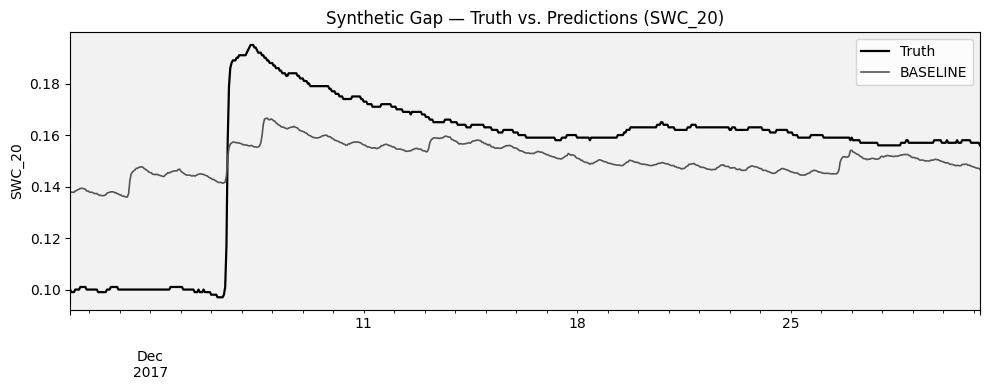


=== RF on gap 0 ===


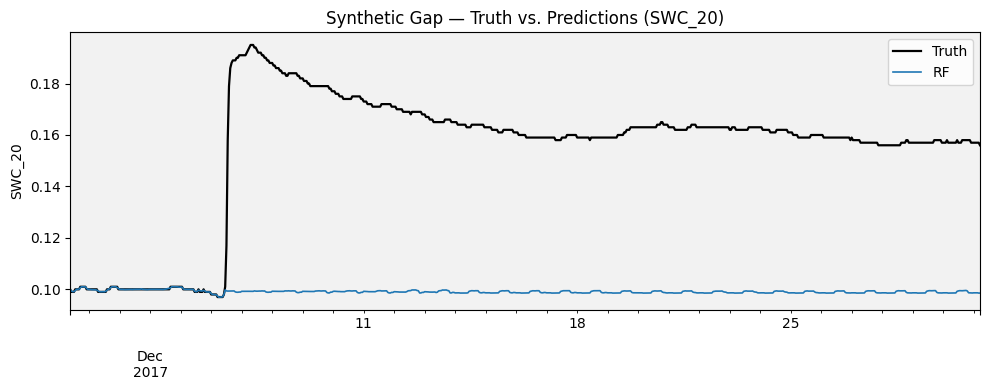


=== LGBM on gap 0 ===


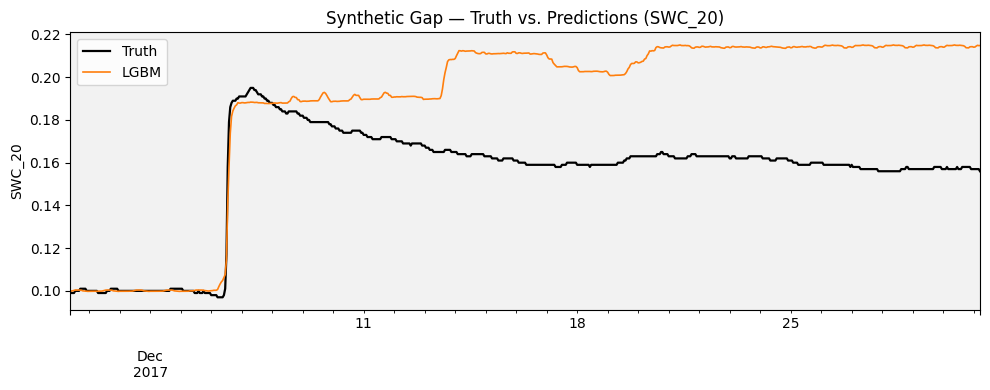


=== XGB on gap 0 ===


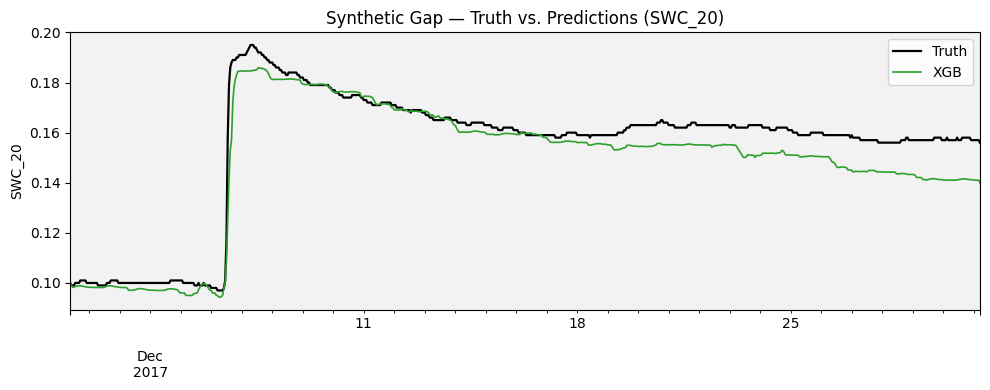

In [17]:
rf_model  = train_random_forest(df_full, PARAM)
lg_model  = train_lightgbm(df_full, PARAM)
xgb_model = train_xgb(df_full, PARAM)

for m in ("baseline", "rf", "lgbm", "xgb"):
    print(f"\n=== {m.upper()} on gap 0 ===")
    plot_one_gap(df_true=df_full,
                 df_work=df_full.copy(),
                 gap=fake_gaps[0],
                 param=PARAM,
                 rf_model=rf_model,
                 lg_model=lg_model,
                 xgb_model=xgb_model,   
                 methods=(m,))
      

In [25]:
def fill_long_gaps_xgb_drift(df, gaps, param):
    model  = train_xgb(df.copy(), param)
    filled = df[param].copy()
    log    = []

    for _, g in gaps.iterrows():
        idx   = pd.date_range(g["Start Timestamp"], g["End Timestamp"], freq="H")
        preds = rolling_fill(model, df.copy(), idx, param)

        filled.loc[idx] = preds
        log.append({"start": g["Start Timestamp"],
                    "end":   g["End Timestamp"],
                    "method": "xgb+drift"})
    return filled, pd.DataFrame(log)

def plot_gap_compare(df_orig: pd.DataFrame,
                     filled_series: pd.Series,
                     gap_row: pd.Series,
                     param: str):
    idx_gap = pd.date_range(gap_row["Start Timestamp"],
                            gap_row["End Timestamp"], freq="H")
    span = pd.date_range(gap_row["Start Timestamp"] - timedelta(days=3),
                         gap_row["End Timestamp"]   + timedelta(days=3), freq="H")

    plt.figure(figsize=(10, 4))
    df_orig[param].loc[span].plot(label="Original", lw=1, color="grey")
    baseline_predict(df_orig[param], idx_gap).plot(label="Baseline", lw=1.5)
    filled_series.loc[idx_gap].plot(label="XGB filled", lw=1.5)
    plt.axvspan(gap_row["Start Timestamp"], gap_row["End Timestamp"],
                color="black", alpha=0.1)
    plt.title(f"Gap {gap_row['Start Timestamp'].date()} – {gap_row['End Timestamp'].date()}  ({param})")
    plt.ylabel(param)
    plt.legend(); plt.tight_layout(); plt.show()


def plot_gap(series, s_ts, e_ts, margin_days=3):
    """
    Plot the imputed series around a single gap for visual inspection.
    """
    window = series.loc[s_ts - timedelta(days=margin_days) : e_ts + timedelta(days=margin_days)]
    plt.figure(figsize=(10, 3.5))
    plt.plot(window.index, window.values, label="Filled Series")
    plt.axvspan(s_ts, e_ts, color='grey', alpha=0.3, label="Gap")
    plt.title(f"{series.name}: {s_ts.date()} → {e_ts.date()}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [19]:
def main(station: int, param: str,
         cleaned_dir: str   = "./output",
         missing_dir: str   = "../EDA_2025/missing_data",
         save_dir:   str    = "./output"):

    print(f"\n>>> Station {station} — Parameter {param}")
    df = load_cleaned_data(station, cleaned_dir)
    df_ref = load_cleaned_data(3, cleaned_dir)
    df["Ppt"] = df["Ppt"].fillna(df_ref["Ppt"]).fillna(0)
    
    gaps = filter_long_gaps(load_missing_data(station, missing_dir), param)

    if gaps.empty:
        print("No long gaps (7–30 days) detected — nothing to fill.")
        return

    filled_series, log = fill_long_gaps_xgb(df.copy(), gaps, param)
    print("Filled", len(gaps), "long gap(s) with XGB.")

    for idx, row in gaps.iterrows():
        s_ts = row["Start Timestamp"]
        e_ts = row["End Timestamp"]
        print(f"\n--- Gap {idx}: {s_ts.date()} → {e_ts.date()} ---")
        plot_gap_compare(df, filled_series, row, param)
        plot_gap(filled_series, s_ts, e_ts, margin_days=3)


>>> Station 1 — Parameter SWC_20
Filled 1 long gap(s) with XGB.

--- Gap 44: 2018-04-12 → 2018-05-06 ---


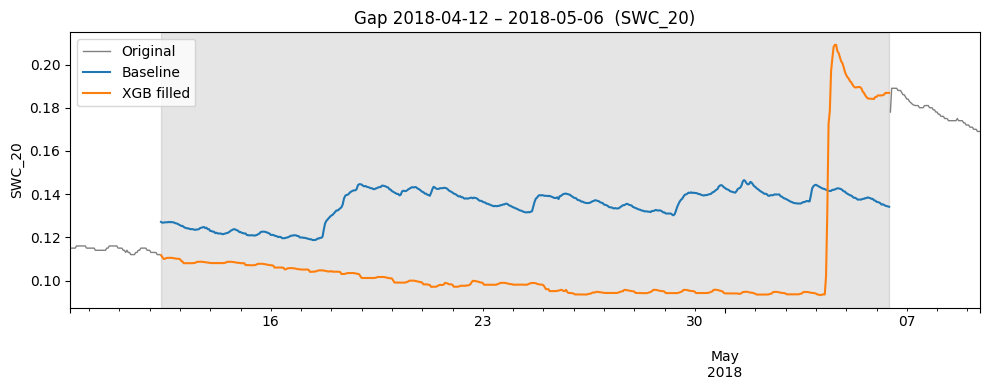

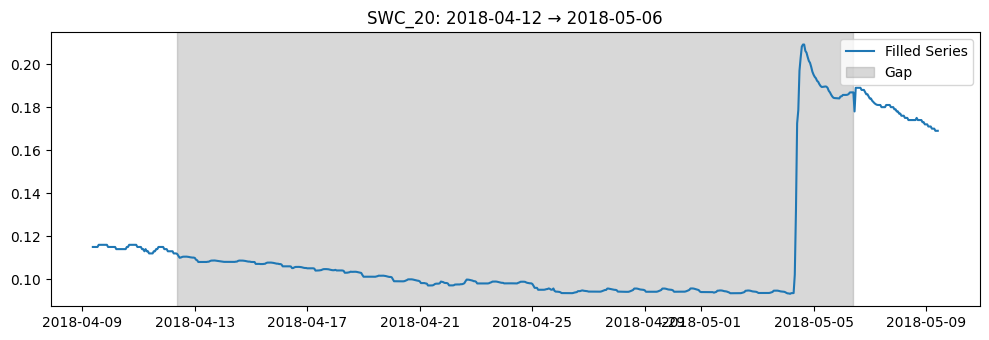

In [26]:
main(1, "SWC_20")

In [14]:
import numpy as np, pandas as pd, itertools
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import timedelta

def eval_one_series(df, param, fake_gaps):
    rf   = train_random_forest(df, param)
    lg   = train_lightgbm(df, param)
    xgb  = train_xgb(df, param)

    rows = []
    for s, e in fake_gaps:
        idx   = pd.date_range(s, e, freq="H")
        truth = df[param].loc[idx].copy()
        df.loc[idx, param] = np.nan          

        preds = {
            "baseline": baseline_predict(df[param], idx),
            "rf"      : rolling_fill(rf,  df, idx, param),
            "lgbm"    : rolling_fill(lg, df, idx, param),
            "xgb"     : rolling_fill(xgb, df, idx, param),
        }

        for m, y_hat in preds.items():
            mse  = mean_squared_error(truth, y_hat)
            mae  = mean_absolute_error(truth, y_hat)
            rmse = mse ** 0.5
            rows.append({
                "Parameter": param,          
                "method":    m,
                "mse":       mse,
                "rmse":      rmse,
                "mae":       mae
            })

        df.loc[idx, param] = truth           
    return pd.DataFrame(rows)


STATIONS = [1, 2, 3, 4, 5, 6]
PARAMS   = ["SWC_5", "SWC_10", "SWC_20", "SWC_50"]

all_metrics = []

for st, pa in itertools.product(STATIONS, PARAMS):
    try:
        df = load_cleaned_data(st)
    except FileNotFoundError:
        continue

    df["Ppt"] = df["Ppt"].fillna(load_cleaned_data(3)["Ppt"]).fillna(0)

    if pa not in df.columns:
        continue

    fake_gaps = make_synthetic_gaps(df[pa], n=5, seed=st * 100 + len(pa))
    all_metrics.append(eval_one_series(df.copy(), pa, fake_gaps))

metrics_df = pd.concat(all_metrics, ignore_index=True)


avg_tbl = (
    metrics_df
    .groupby("method")[["mse", "rmse", "mae"]]
    .mean()
    .round(5)
)
print("\n=== Average over ALL parameters & stations ===")
display(avg_tbl)


param_summary = (
    metrics_df
    .groupby(["Parameter", "method"])[["mse", "rmse", "mae"]]
    .mean()
    .round(5)
    .reset_index()
)

print("\n=== Average per Parameter ===")
display(param_summary.set_index(["Parameter", "method"]))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1925
[LightGBM] [Info] Number of data points in the train set: 57863, number of used features: 10
[LightGBM] [Info] Start training from score 0.143011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1872
[LightGBM] [Info] Number of data points in the train set: 57863, number of used features: 10
[LightGBM] [Info] Start training from score 0.156682
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

ValueError: a cannot be empty unless no samples are taken

In [16]:
import pandas as pd, pathlib

out_partial = pathlib.Path("partial_longgap_metrics.csv")
pd.concat(all_metrics, ignore_index=True).to_csv(out_partial, index=False)

done = set()           # {(station, param)}
if out_partial.exists():
    done_df = pd.read_csv(out_partial)
    done = {(row.Station, row.Parameter)          
            for _, row in done_df.iterrows()}    
for st, pa in itertools.product(STATIONS, PARAMS):
    if (st, pa) in done:
        continue          
    ...
    m = eval_one_series(...)
    
    m.to_csv(out_partial, mode="a",
             header=not out_partial.exists(), index=False)
try:
    fake_gaps = make_synthetic_gaps(...)
except ValueError:
    print(f"Skip {st}-{pa}: not enough continuous data")
    continue
if not fake_gaps:
    continue

✅ 已将 15 组结果写入: partial_longgap_metrics.csv


AttributeError: 'Series' object has no attribute 'Station'

In [17]:
import pandas as pd, pathlib

out_partial = pathlib.Path("partial_longgap_metrics.csv")
done_params = set()                     

if out_partial.exists():
    done_df = pd.read_csv(out_partial)
    done_params = set(done_df["Parameter"].unique())
    print("已完成参数：", done_params)

for st, pa in itertools.product(STATIONS, PARAMS):
    if pa in done_params:                
        continue

    try:
        df = load_cleaned_data(st)
    except FileNotFoundError:
        continue

    df["Ppt"] = df["Ppt"].fillna(load_cleaned_data(3)["Ppt"]).fillna(0)
    if pa not in df.columns:
        continue

    try:
        fake_gaps = make_synthetic_gaps(df[pa], n=5,
                                        seed=st * 100 + len(pa))
    except ValueError:
        print(f"Skip {st}-{pa}: insufficient continuous data.")
        continue
    if not fake_gaps:
        continue

    m = eval_one_series(df.copy(), pa, fake_gaps)
    
    m.to_csv(out_partial, mode="a",
             header=not out_partial.exists(), index=False)

    
    done_params.add(pa)


已完成参数： {'SWC_50', 'SWC_20', 'SWC_10', 'SWC_5'}


In [18]:
metrics_df = pd.read_csv("partial_longgap_metrics.csv")
avg_tbl = metrics_df.groupby("method")[["mse","rmse","mae"]].mean().round(5)
param_summary = (metrics_df
                 .groupby(["Parameter","method"])[["mse","rmse","mae"]]
                 .mean().round(5))
display(avg_tbl)
display(param_summary)

,mse,rmse,mae
method,,,
baseline,0.00321,0.05151,0.04678
lgbm,0.00179,0.03316,0.02809
rf,0.00077,0.02022,0.01497
xgb,0.00025,0.01208,0.00934


mse     rmse      mae
Parameter method                             
SWC_10    baseline  0.00338  0.05427  0.04913
          lgbm      0.00225  0.03880  0.03308
          rf        0.00094  0.02503  0.01812
          xgb       0.00033  0.01348  0.01020
SWC_20    baseline  0.00326  0.05234  0.04741
          lgbm      0.00180  0.03467  0.02881
          rf        0.00045  0.01686  0.01197
          xgb       0.00015  0.00991  0.00740
SWC_5     baseline  0.00290  0.05086  0.04504
          lgbm      0.00233  0.03806  0.03276
          rf        0.00134  0.02632  0.02010
          xgb       0.00028  0.01374  0.01065
SWC_50    baseline  0.00335  0.04758  0.04510
          lgbm      0.00046  0.01709  0.01426
          rf        0.00021  0.01018  0.00794
          xgb       0.00024  0.01090  0.00905